In [5]:
import kagglehub
import os
import pandas as pd

# Download latest version
path = kagglehub.dataset_download("sijovm/used-cars-data-from-ebay-kleinanzeigen")

print("Path to dataset files:", path)

# List files in the downloaded path to identify the data file
files = os.listdir(path)
print("Files in dataset directory:", files)

# Assuming the main data file is a CSV and taking the first one found
csv_files = [f for f in files if f.endswith('.csv')]
data_file = os.path.join(path, csv_files[0])
autos = pd.read_csv(data_file, encoding='latin1')
print("Data loaded into 'autos' variable.")




100%|██████████| 17.2M/17.2M [00:01<00:00, 10.1MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/sijovm/used-cars-data-from-ebay-kleinanzeigen/versions/1
Files in dataset directory: ['autos.csv']
Data loaded into 'autos' variable.


In [6]:
print("First 5 rows of 'auto':\n", autos.head())
print(autos.info())

First 5 rows of 'auto':
            dateCrawled                            name  seller offerType  \
0  2016-03-24 11:52:17                      Golf_3_1.6  privat   Angebot   
1  2016-03-24 10:58:45            A5_Sportback_2.7_Tdi  privat   Angebot   
2  2016-03-14 12:52:21  Jeep_Grand_Cherokee_"Overland"  privat   Angebot   
3  2016-03-17 16:54:04              GOLF_4_1_4__3TÜRER  privat   Angebot   
4  2016-03-31 17:25:20  Skoda_Fabia_1.4_TDI_PD_Classic  privat   Angebot   

   price abtest vehicleType  yearOfRegistration    gearbox  powerPS  model  \
0    480   test         NaN                1993    manuell        0   golf   
1  18300   test       coupe                2011    manuell      190    NaN   
2   9800   test         suv                2004  automatik      163  grand   
3   1500   test  kleinwagen                2001    manuell       75   golf   
4   3600   test  kleinwagen                2008    manuell       69  fabia   

   kilometer  monthOfRegistration fuelType       

In [7]:
print(autos.columns)

Index(['dateCrawled', 'name', 'seller', 'offerType', 'price', 'abtest',
       'vehicleType', 'yearOfRegistration', 'gearbox', 'powerPS', 'model',
       'kilometer', 'monthOfRegistration', 'fuelType', 'brand',
       'notRepairedDamage', 'dateCreated', 'nrOfPictures', 'postalCode',
       'lastSeen'],
      dtype='object')


In [8]:
# Define a dictionary for renaming columns for better readability
new_column_names = {
    'dateCrawled': 'crawling_date',
    'yearOfRegistration': 'registration_year',
    'monthOfRegistration': 'registration_month',
    'notRepairedDamage': 'unrepaired_damage',
    'dateCreated': 'ad_created_date',
    'powerPS': 'power_ps'
}

# Rename the columns
autos = autos.rename(columns=new_column_names)

print("Columns after renaming:")
print(autos.columns)

Columns after renaming:
Index(['crawling_date', 'name', 'seller', 'offerType', 'price', 'abtest',
       'vehicleType', 'registration_year', 'gearbox', 'power_ps', 'model',
       'kilometer', 'registration_month', 'fuelType', 'brand',
       'unrepaired_damage', 'ad_created_date', 'nrOfPictures', 'postalCode',
       'lastSeen'],
      dtype='object')


Changed column names from camel case to better conform with python norms

## Exploring 'kilometer' (Odometer) and 'price' Columns

Let's analyze the `kilometer` and `price` columns using descriptive statistics and visualizations to understand their distributions, potential outliers, and relationships.

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Display descriptive statistics for 'kilometer' and 'price'
print("Descriptive statistics for 'kilometer':\n", autos['kilometer'].describe())
print("\nDescriptive statistics for 'price':\n", autos['price'].describe())

# Check for zero values in 'price' and 'kilometer'
print("\nNumber of entries with price = 0:", autos[autos['price'] == 0].shape[0])
print("Number of entries with kilometer = 0:", autos[autos['kilometer'] == 0].shape[0])

Descriptive statistics for 'kilometer':
 count    371528.000000
mean     125618.688228
std       40112.337051
min        5000.000000
25%      125000.000000
50%      150000.000000
75%      150000.000000
max      150000.000000
Name: kilometer, dtype: float64

Descriptive statistics for 'price':
 count    3.715280e+05
mean     1.729514e+04
std      3.587954e+06
min      0.000000e+00
25%      1.150000e+03
50%      2.950000e+03
75%      7.200000e+03
max      2.147484e+09
Name: price, dtype: float64

Number of entries with price = 0: 10778
Number of entries with kilometer = 0: 0


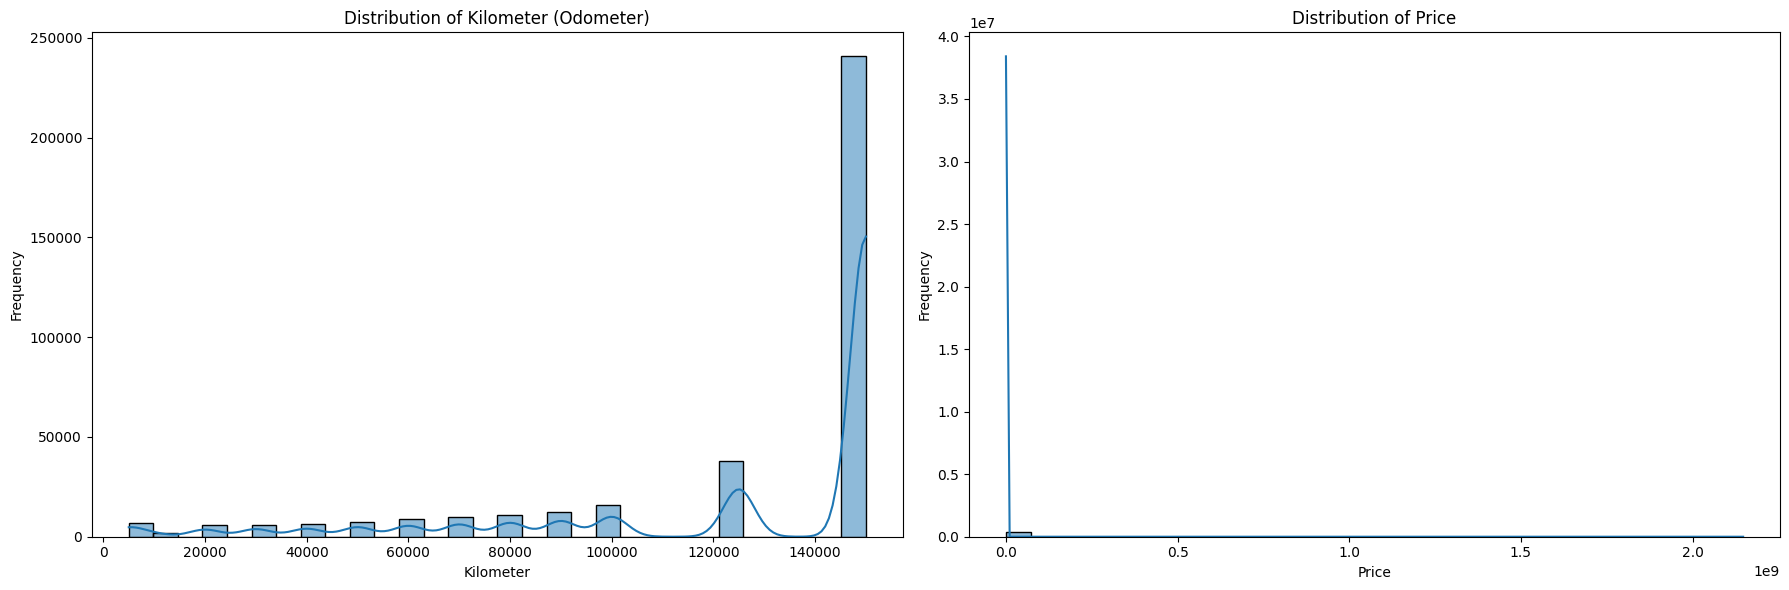

In [10]:
# Set up the matplotlib figure and axes
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Histogram for 'kilometer'
sns.histplot(autos['kilometer'], bins=30, kde=True, ax=axes[0])
axes[0].set_title('Distribution of Kilometer (Odometer)')
axes[0].set_xlabel('Kilometer')
axes[0].set_ylabel('Frequency')

# Histogram for 'price'
sns.histplot(autos['price'], bins=30, kde=True, ax=axes[1])
axes[1].set_title('Distribution of Price')
axes[1].set_xlabel('Price')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()


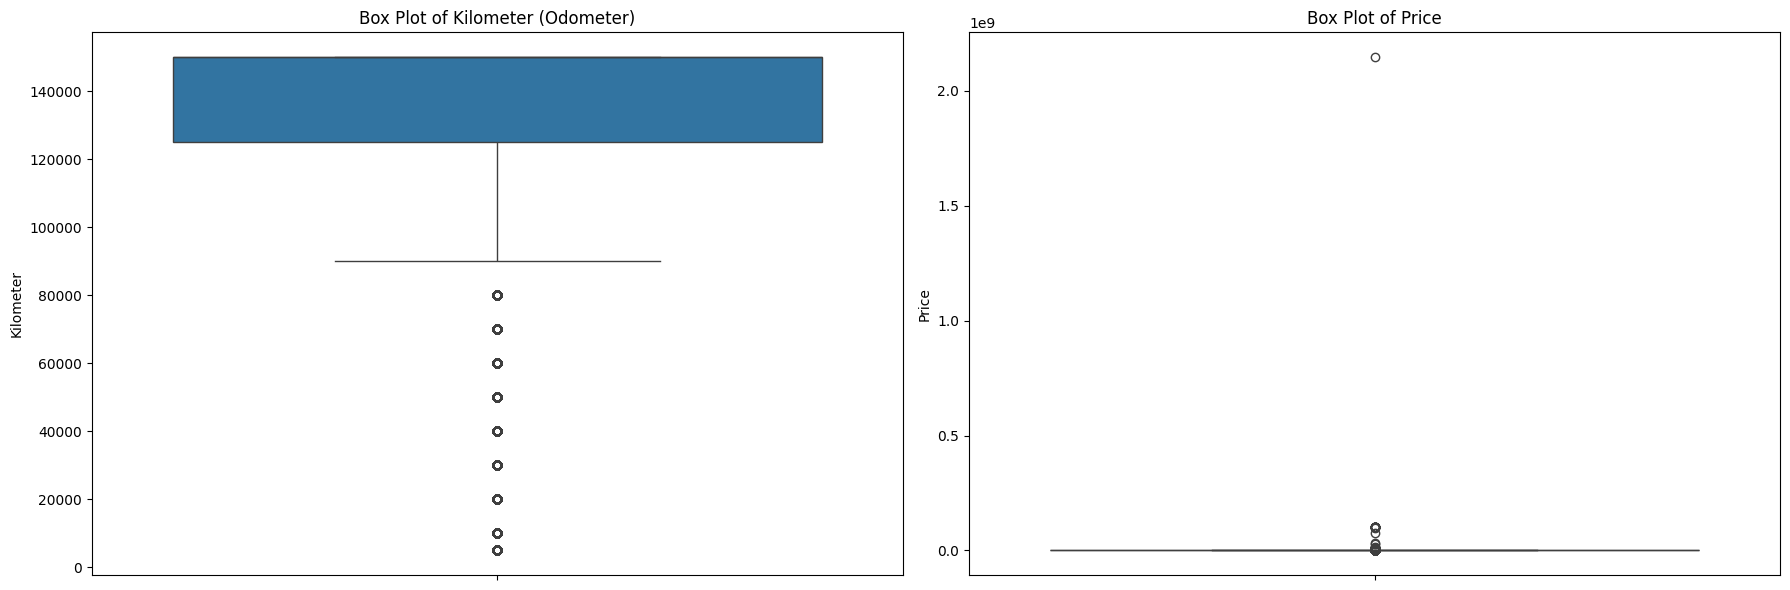

In [11]:
# Box plot for 'kilometer'
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.boxplot(y=autos['kilometer'], ax=axes[0])
axes[0].set_title('Box Plot of Kilometer (Odometer)')
axes[0].set_ylabel('Kilometer')

# Box plot for 'price'
sns.boxplot(y=autos['price'], ax=axes[1])
axes[1].set_title('Box Plot of Price')
axes[1].set_ylabel('Price')

plt.tight_layout()
plt.show()


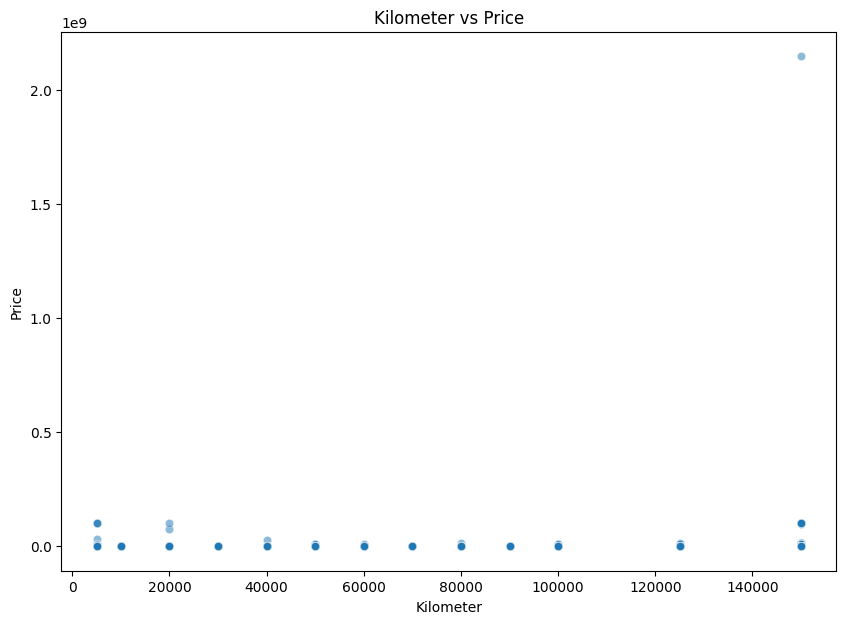

In [12]:
# Scatter plot of 'kilometer' vs 'price'
plt.figure(figsize=(10, 7))
sns.scatterplot(x=autos['kilometer'], y=autos['price'], alpha=0.5)
plt.title('Kilometer vs Price')
plt.xlabel('Kilometer')
plt.ylabel('Price')
plt.show()


## Data Cleaning for 'price' and 'kilometer'

Based on the initial exploration, we need to clean the `price` column by removing zero values and extreme outliers. We will also define reasonable bounds for both `price` and `kilometer` to ensure data quality for further analysis.

In [13]:
# Remove entries where price is 0
print(f"Original number of entries: {autos.shape[0]}")
autos_cleaned = autos[autos['price'] > 0].copy()
print(f"Number of entries after removing price = 0: {autos_cleaned.shape[0]}")

# Define reasonable price and kilometer ranges based on domain knowledge and observations
# Assuming prices below 50 are too low and above 500,000 are too high (outliers)
# Assuming kilometer values below 5000 or above 200,000 are outliers (though current data maxes at 150k)
min_price = 50
max_price = 500000
min_kilometer = 5000
max_kilometer = 200000

# Apply filters
autos_cleaned = autos_cleaned[
    (autos_cleaned['price'] >= min_price) & (autos_cleaned['price'] <= max_price) &
    (autos_cleaned['kilometer'] >= min_kilometer) & (autos_cleaned['kilometer'] <= max_kilometer)
].copy()

print(f"Number of entries after applying price and kilometer filters: {autos_cleaned.shape[0]}")

# Re-display descriptive statistics for the cleaned data
print("\nDescriptive statistics for 'kilometer' (cleaned):\n", autos_cleaned['kilometer'].describe())
print("\nDescriptive statistics for 'price' (cleaned):\n", autos_cleaned['price'].describe())

Original number of entries: 371528
Number of entries after removing price = 0: 360750
Number of entries after applying price and kilometer filters: 358999

Descriptive statistics for 'kilometer' (cleaned):
 count    358999.000000
mean     125771.798807
std       39661.584626
min        5000.000000
25%      125000.000000
50%      150000.000000
75%      150000.000000
max      150000.000000
Name: kilometer, dtype: float64

Descriptive statistics for 'price' (cleaned):
 count    358999.000000
mean       5943.697506
std        9306.001136
min          50.000000
25%        1250.000000
50%        3099.000000
75%        7499.000000
max      500000.000000
Name: price, dtype: float64


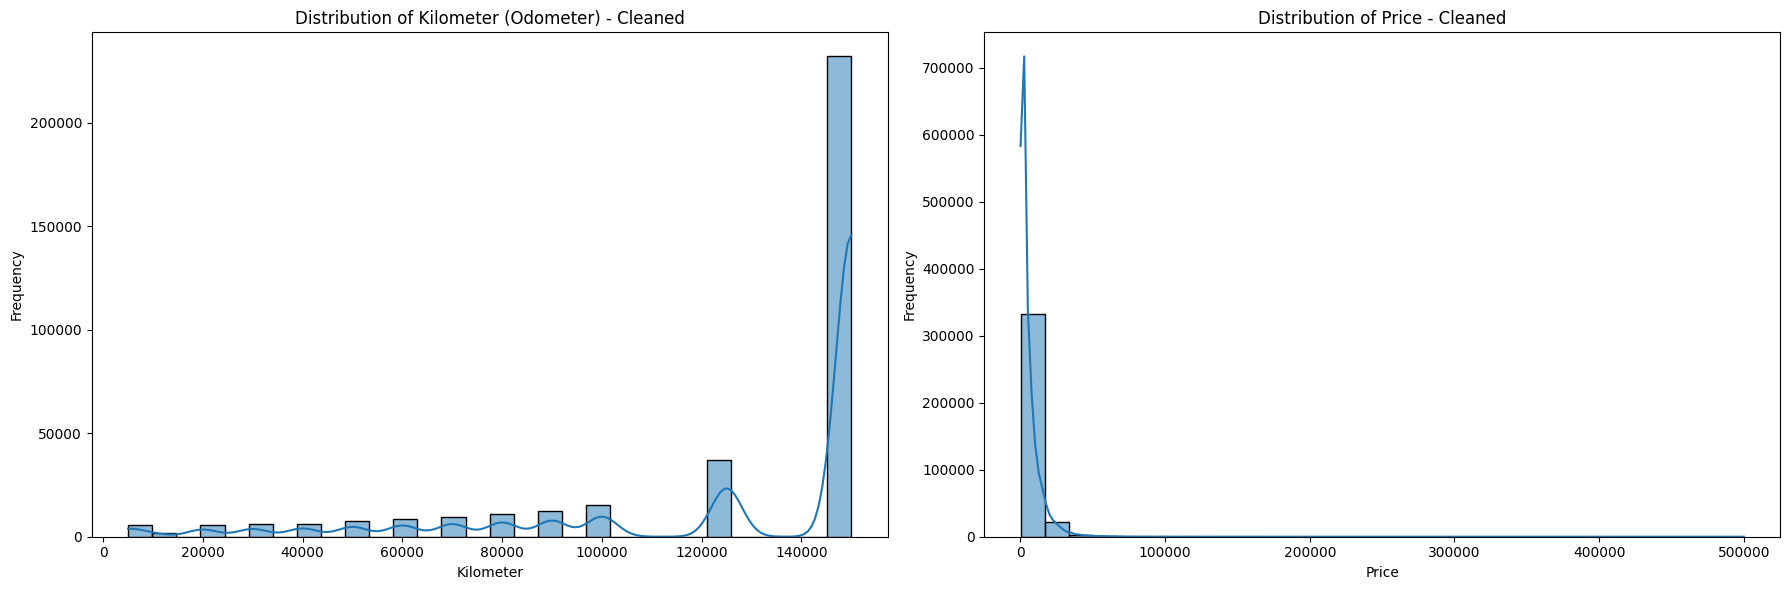

In [14]:
# Re-plot histograms for cleaned 'kilometer' and 'price'
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.histplot(autos_cleaned['kilometer'], bins=30, kde=True, ax=axes[0])
axes[0].set_title('Distribution of Kilometer (Odometer) - Cleaned')
axes[0].set_xlabel('Kilometer')
axes[0].set_ylabel('Frequency')

sns.histplot(autos_cleaned['price'], bins=30, kde=True, ax=axes[1])
axes[1].set_title('Distribution of Price - Cleaned')
axes[1].set_xlabel('Price')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()


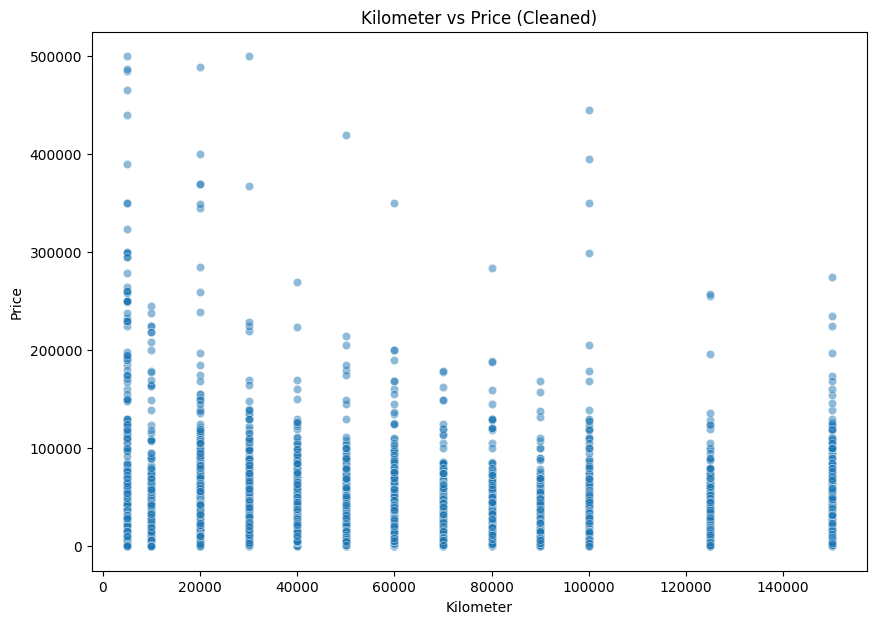

In [15]:
# Re-plot scatter plot for cleaned 'kilometer' vs 'price'
plt.figure(figsize=(10, 7))
sns.scatterplot(x=autos_cleaned['kilometer'], y=autos_cleaned['price'], alpha=0.5)
plt.title('Kilometer vs Price (Cleaned)')
plt.xlabel('Kilometer')
plt.ylabel('Price')
plt.show()


## Further Breakdown of 'price' Distribution

Let's get a more granular understanding of the `price` distribution using detailed descriptive statistics and additional visualizations like box plots and violin plots.

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure autos_cleaned is defined if the kernel state was reset
# Assuming 'autos' is available from previous cells.
autos_cleaned = autos[autos['price'] > 0].copy()
min_price = 50
max_price = 500000
min_kilometer = 5000
max_kilometer = 200000
autos_cleaned = autos_cleaned[
    (autos_cleaned['price'] >= min_price) & (autos_cleaned['price'] <= max_price) &
    (autos_cleaned['kilometer'] >= min_kilometer) & (autos_cleaned['kilometer'] <= max_kilometer)
].copy()

print("Detailed descriptive statistics for 'price' (cleaned data):\n", autos_cleaned['price'].describe(percentiles=[.1, .25, .5, .75, .9, .95, .99]))

Detailed descriptive statistics for 'price' (cleaned data):
 count    358999.000000
mean       5943.697506
std        9306.001136
min          50.000000
10%         600.000000
25%        1250.000000
50%        3099.000000
75%        7499.000000
90%       14490.000000
95%       19900.000000
99%       36000.000000
max      500000.000000
Name: price, dtype: float64


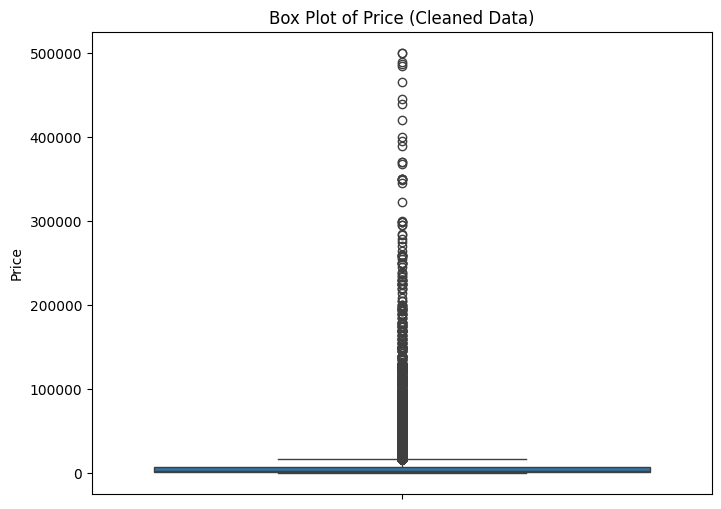

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure autos_cleaned is defined if the kernel state was reset
# Assuming 'autos' is available from previous cells.
autos_cleaned = autos[autos['price'] > 0].copy()
min_price = 50
max_price = 500000
min_kilometer = 5000
max_kilometer = 200000
autos_cleaned = autos_cleaned[
    (autos_cleaned['price'] >= min_price) & (autos_cleaned['price'] <= max_price) &
    (autos_cleaned['kilometer'] >= min_kilometer) & (autos_cleaned['kilometer'] <= max_kilometer)
].copy()

# Box plot for 'price' (cleaned data)
plt.figure(figsize=(8, 6))
sns.boxplot(y=autos_cleaned['price'])
plt.title('Box Plot of Price (Cleaned Data)')
plt.ylabel('Price')
plt.show()

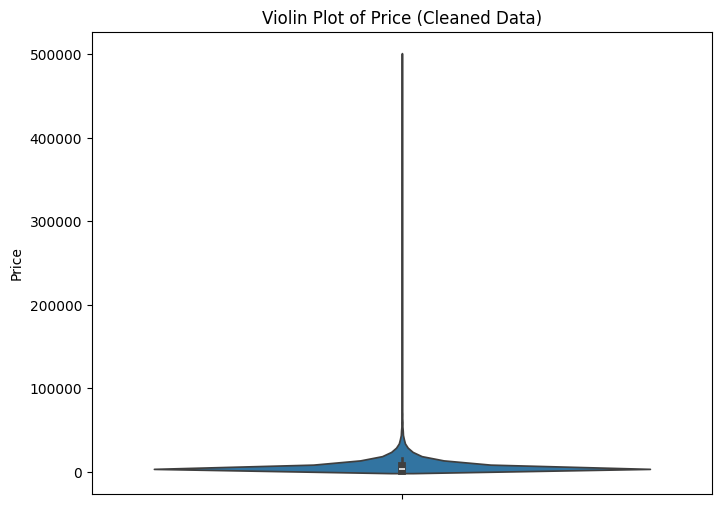

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure autos_cleaned is defined if the kernel state was reset
# Assuming 'autos' is available from previous cells.
autos_cleaned = autos[autos['price'] > 0].copy()
min_price = 50
max_price = 500000
min_kilometer = 5000
max_kilometer = 200000
autos_cleaned = autos_cleaned[
    (autos_cleaned['price'] >= min_price) & (autos_cleaned['price'] <= max_price) &
    (autos_cleaned['kilometer'] >= min_kilometer) & (autos_cleaned['kilometer'] <= max_kilometer)
].copy()

# Violin plot for 'price' (cleaned data)
plt.figure(figsize=(8, 6))
sns.violinplot(y=autos_cleaned['price'])
plt.title('Violin Plot of Price (Cleaned Data)')
plt.ylabel('Price')
plt.show()

## Exploring and Cleaning Date Columns

We will now examine the various date-related columns in the dataset: `crawling_date`, `ad_created_date`, `lastSeen`, `registration_year`, and `registration_month`. The goal is to convert them to appropriate datetime formats, check for data consistency, and address any incorrect values, particularly in `registration_year`.

### Convert Date Columns to Datetime Objects

In [19]:
import pandas as pd

# Ensure autos_cleaned is defined if the kernel state was reset
# The previous cell already ensures this, but for standalone execution, it's good practice.
if 'autos_cleaned' not in locals():
    # Re-create autos_cleaned from the original 'autos' DataFrame based on previous cleaning steps
    autos_cleaned = autos[autos['price'] > 0].copy()
    min_price = 50
    max_price = 500000
    min_kilometer = 5000
    max_kilometer = 200000
    autos_cleaned = autos_cleaned[
        (autos_cleaned['price'] >= min_price) & (autos_cleaned['price'] <= max_price) &
        (autos_cleaned['kilometer'] >= min_kilometer) & (autos_cleaned['kilometer'] <= max_kilometer)
    ].copy()

# Convert date columns to datetime objects
autos_cleaned['crawling_date'] = pd.to_datetime(autos_cleaned['crawling_date'])
autos_cleaned['ad_created_date'] = pd.to_datetime(autos_cleaned['ad_created_date'])
autos_cleaned['lastSeen'] = pd.to_datetime(autos_cleaned['lastSeen'])

print("Data types after converting date columns:")
print(autos_cleaned[['crawling_date', 'ad_created_date', 'lastSeen']].info())

Data types after converting date columns:
<class 'pandas.core.frame.DataFrame'>
Index: 358999 entries, 0 to 371527
Data columns (total 3 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   crawling_date    358999 non-null  datetime64[ns]
 1   ad_created_date  358999 non-null  datetime64[ns]
 2   lastSeen         358999 non-null  datetime64[ns]
dtypes: datetime64[ns](3)
memory usage: 11.0 MB
None


### Analyze `registration_year` and `registration_month`

The `registration_year` and `registration_month` columns represent the first registration date of the vehicle. We need to ensure these values are realistic, meaning the registration year should not be too far in the past (e.g., before cars existed) or in the future (after the `crawling_date`).

In [20]:
# Get the distribution of registration years
print("Distribution of registration_year:")
print(autos_cleaned['registration_year'].value_counts().sort_index().head())
print(autos_cleaned['registration_year'].value_counts().sort_index().tail())

# Check for unrealistic registration years
# A common range for cars is from 1900 to the current year or slightly after the crawling date.
current_year = pd.Timestamp.now().year

# Assuming an upper bound for registration year is the year of the latest `lastSeen` date plus a small margin,
# or simply the current year. We'll use the maximum year from `crawling_date` + 1 to be safe.
max_crawling_year = autos_cleaned['crawling_date'].dt.year.max()
upper_bound_year = max_crawling_year + 1 # Cars shouldn't be registered after they are crawled

# Filter out unrealistic registration years
# Let's consider 1900 as a reasonable lower bound for car manufacturing.
valid_registration_years = autos_cleaned[
    (autos_cleaned['registration_year'] >= 1900) &
    (autos_cleaned['registration_year'] <= upper_bound_year)
].copy()

# Calculate the percentage of invalid entries
invalid_reg_year_count = autos_cleaned.shape[0] - valid_registration_years.shape[0]
invalid_reg_year_percentage = (invalid_reg_year_count / autos_cleaned.shape[0]) * 100

print(f"\nNumber of entries with unrealistic registration_year: {invalid_reg_year_count}")
print(f"Percentage of entries with unrealistic registration_year: {invalid_reg_year_percentage:.2f}%")

# Update the DataFrame to only include valid registration years
autos_cleaned = valid_registration_years

print(f"\nNumber of entries after filtering unrealistic registration_year: {autos_cleaned.shape[0]}")

Distribution of registration_year:
registration_year
1000    26
1001     1
1039     1
1111     1
1234     4
Name: count, dtype: int64
registration_year
8500     1
8888     2
9000     4
9450     1
9999    18
Name: count, dtype: int64

Number of entries with unrealistic registration_year: 3951
Percentage of entries with unrealistic registration_year: 1.10%

Number of entries after filtering unrealistic registration_year: 355048


### Visualizing `registration_year` Distribution (Cleaned)

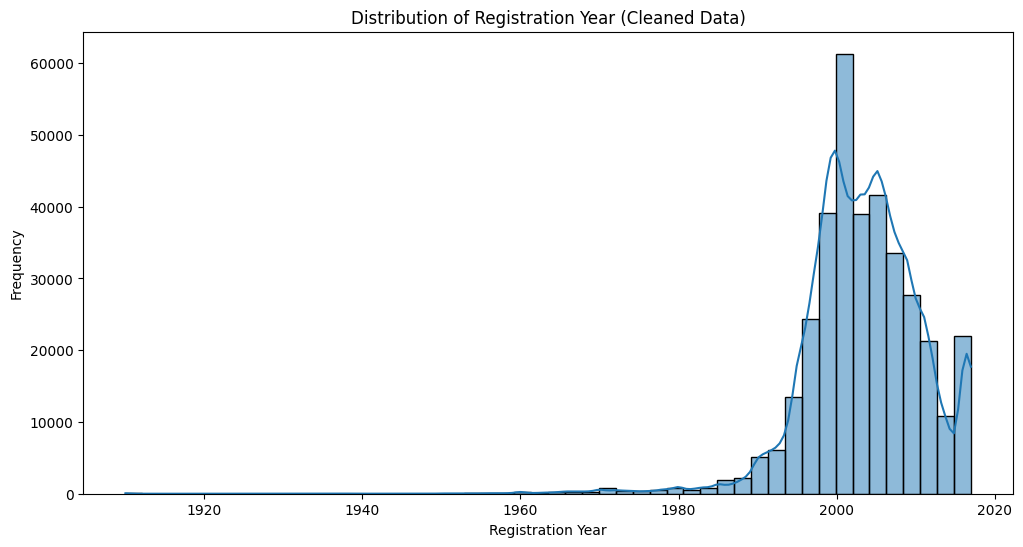

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.histplot(autos_cleaned['registration_year'], bins=50, kde=True)
plt.title('Distribution of Registration Year (Cleaned Data)')
plt.xlabel('Registration Year')
plt.ylabel('Frequency')
plt.show()

### Relationship between Registration Year and Price

Let's visualize how the `registration_year` relates to the `price` of the cars.

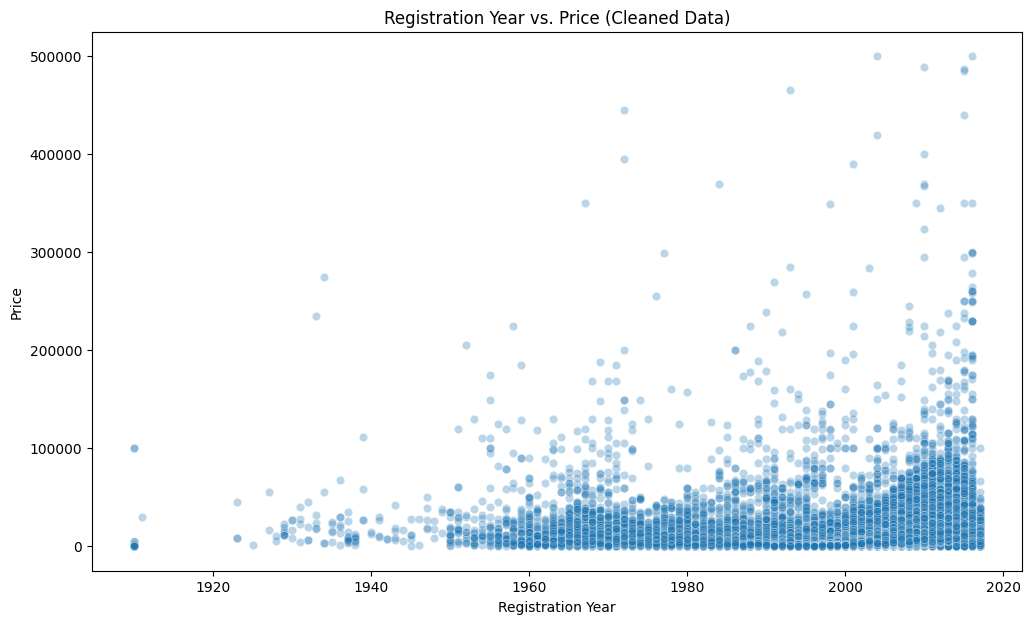

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 7))
sns.scatterplot(x=autos_cleaned['registration_year'], y=autos_cleaned['price'], alpha=0.3)
plt.title('Registration Year vs. Price (Cleaned Data)')
plt.xlabel('Registration Year')
plt.ylabel('Price')
plt.show()

## Exploring Price by Brand

To understand how car prices differ across brands, we'll perform the following steps:
1.  Group the `autos_cleaned` DataFrame by the 'brand' column.
2.  Calculate descriptive statistics (mean, median, min, max price) for each brand.
3.  Count the number of listings per brand to assess popularity or availability.
4.  Store this aggregated data in a new DataFrame.
5.  Display the top and bottom brands based on their average price.
6.  Visualize the average price per brand using a bar plot to highlight significant differences.

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure autos_cleaned is available before proceeding
if 'autos_cleaned' not in locals() or autos_cleaned.empty:
    print("'autos_cleaned' DataFrame is not available or is empty. Please ensure previous cleaning steps were executed successfully.")
else:
    # Group by brand and calculate relevant statistics
    brand_price_stats = autos_cleaned.groupby('brand')['price'].agg(
        mean_price='mean',
        median_price='median',
        min_price='min',
        max_price='max',
        listing_count='count'
    ).reset_index()

    # Sort by mean price for better analysis
    brand_price_stats = brand_price_stats.sort_values(by='mean_price', ascending=False)

    print("### Brand Price Statistics (Top 10 by Mean Price):\n")
    display(brand_price_stats.head(10))

    print("\n### Brand Price Statistics (Bottom 10 by Mean Price):\n")
    display(brand_price_stats.tail(10))

    # Optionally, save this aggregated data to a new DataFrame for later use
    autos_brand_summary = brand_price_stats.copy()

    print("\nAggregated brand price summary saved to 'autos_brand_summary' DataFrame.")
    print(f"Shape of 'autos_brand_summary': {autos_brand_summary.shape}")

### Brand Price Statistics (Top 10 by Mean Price):



,brand,mean_price,median_price,min_price,max_price,listing_count
26,porsche,43965.062413,31313.0,65,500000,2147
18,land_rover,17024.399204,12700.0,220,120000,754
33,sonstige_autos,15202.243085,6499.0,50,500000,3254
13,jaguar,14641.420266,6400.0,50,466000,602
14,jeep,11124.934194,7450.0,60,59800,775
21,mini,10011.858135,8700.0,70,45000,3313
1,audi,9026.300667,5999.0,50,323223,31623
20,mercedes_benz,8524.697877,5000.0,50,368000,34198
2,bmw,8435.932024,5900.0,50,390000,38646
3,chevrolet,7125.658357,4600.0,50,90500,1765



### Brand Price Statistics (Bottom 10 by Mean Price):



,brand,mean_price,median_price,min_price,max_price,listing_count
17,lancia,3292.373102,1199.0,50,64000,461
25,peugeot,3249.951631,2299.0,50,31500,10668
16,lada,3191.425121,2800.0,99,12390,207
24,opel,2962.255882,1600.0,50,100000,38037
9,fiat,2881.029268,1648.0,50,49000,9191
27,renault,2423.788088,1350.0,50,110000,17059
37,trabant,1981.012552,1300.0,50,14500,478
8,daihatsu,1769.996068,1000.0,50,12850,763
28,rover,1598.231441,994.0,50,28900,458
7,daewoo,1039.603810,999.0,60,4200,525



Aggregated brand price summary saved to 'autos_brand_summary' DataFrame.
Shape of 'autos_brand_summary': (40, 6)


### Visualizing Average Price by Brand

Let's visualize the average price for the top 20 brands to see the differences more clearly.

/tmp/ipykernel_936/787568316.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='mean_price', y='brand', data=autos_brand_summary.head(20), palette='viridis')


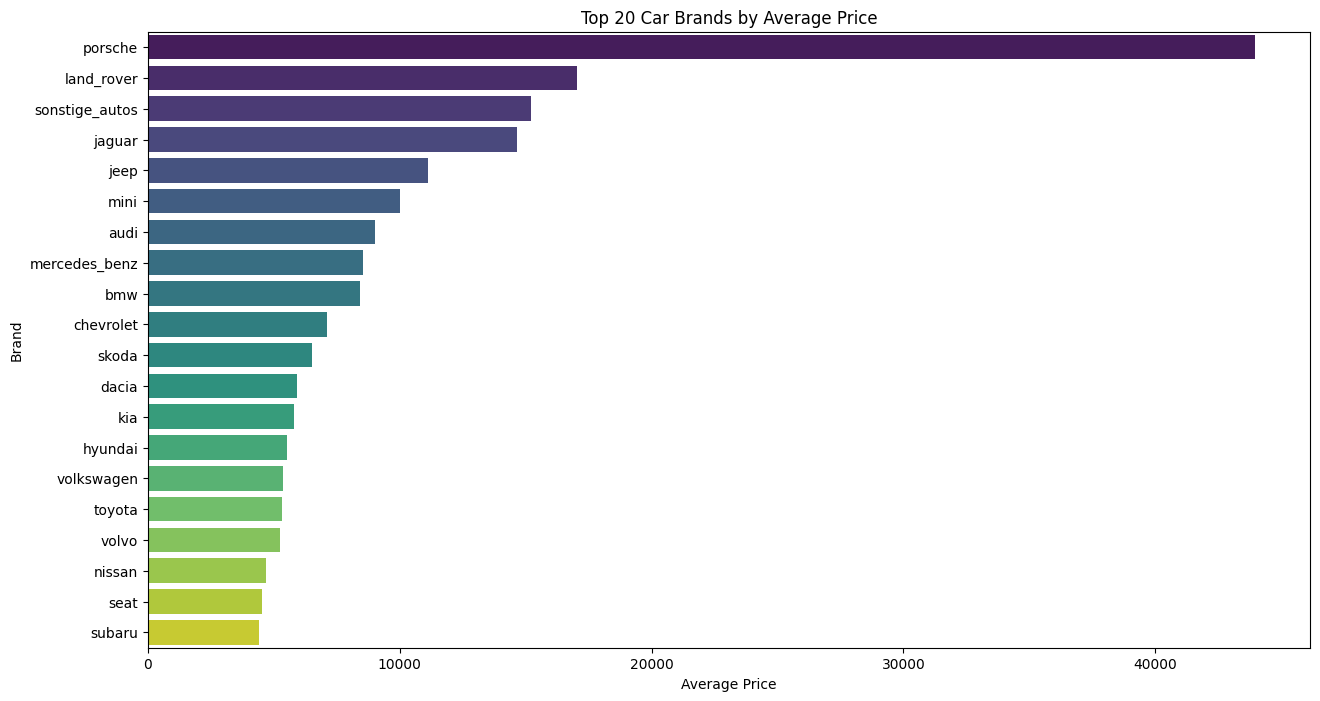

/tmp/ipykernel_936/787568316.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='mean_price', y='brand', data=autos_brand_summary.tail(20), palette='magma')


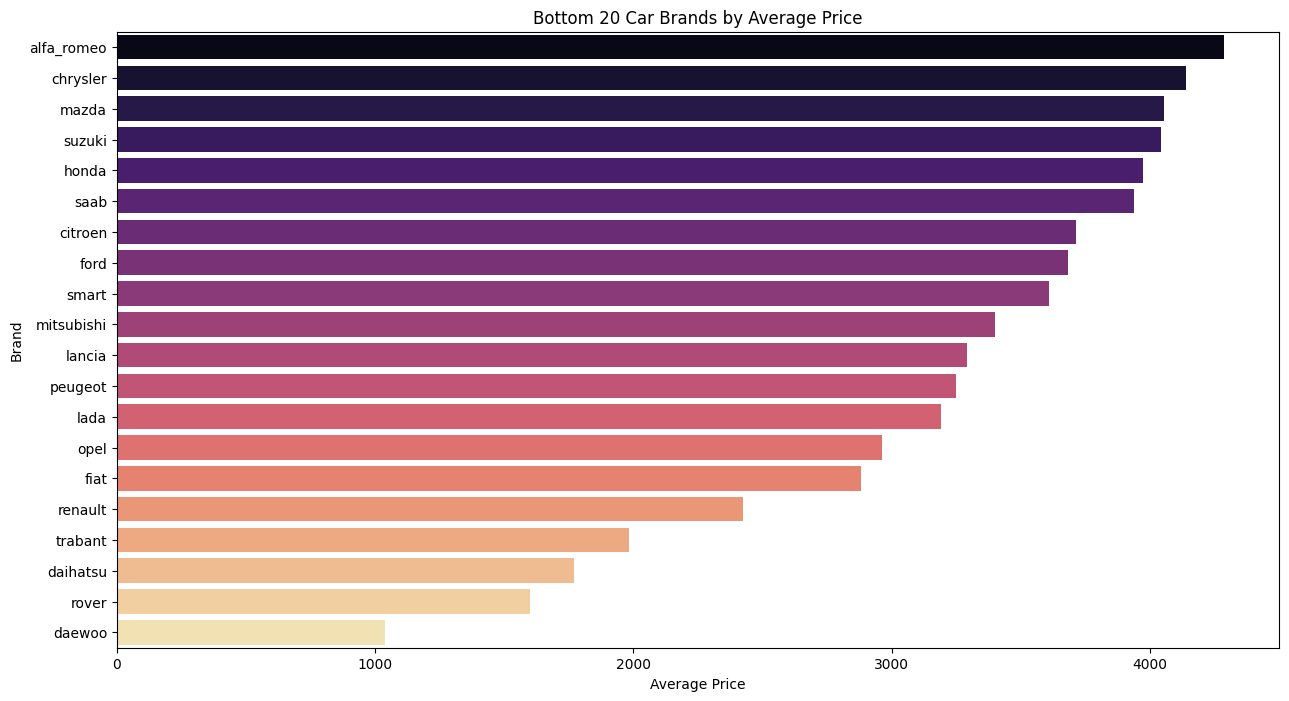

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

if 'autos_brand_summary' in locals() and not autos_brand_summary.empty:
    # Plotting the top 20 brands by mean price
    plt.figure(figsize=(15, 8))
    sns.barplot(x='mean_price', y='brand', data=autos_brand_summary.head(20), palette='viridis')
    plt.title('Top 20 Car Brands by Average Price')
    plt.xlabel('Average Price')
    plt.ylabel('Brand')
    plt.show()

    # Plotting the bottom 20 brands by mean price
    plt.figure(figsize=(15, 8))
    sns.barplot(x='mean_price', y='brand', data=autos_brand_summary.tail(20), palette='magma')
    plt.title('Bottom 20 Car Brands by Average Price')
    plt.xlabel('Average Price')
    plt.ylabel('Brand')
    plt.show()
else:
    print("'autos_brand_summary' DataFrame is not available or is empty. Cannot generate visualizations.")

## Conclusions and Important Information

Throughout this notebook, we've performed an initial exploration and cleaning of the used car sales dataset. We focused on standardizing column names, handling outliers in `price` and `kilometer` columns, examining date columns, and finally, analyzing car prices by brand.

### Summary of Data Cleaning:

*   **Initial Data:** The dataset contained `371,528` entries.
*   **Price and Kilometer Cleaning:** We removed entries with unrealistic prices (price = 0, or outside `50-500,000` range) and kilometer values (outside `5,000-200,000` km range). This reduced the dataset to `358,999` entries.
*   **Registration Year Cleaning:** We identified and removed `3,951` entries with unrealistic registration years (before 1900 or after the crawling date + 1). The final cleaned dataset `autos_cleaned` contains `355,048` entries.
*   **Date Columns:** `crawling_date`, `ad_created_date`, and `lastSeen` were successfully converted to datetime objects, and `registration_year` was analyzed for consistency.

### Key Insights from Brand Price Analysis:

The analysis of car prices across different brands revealed significant variations, indicating distinct market segments:

*   **Premium Brands:** Brands such as Porsche, Land Rover, and Jaguar consistently commanded the highest average prices.
*   **Economy Brands:** Conversely, brands like Daewoo, Rover, and Trabant were found at the lower end of the price spectrum.
*   **Market Distribution:** The visualizations clearly demonstrated these price disparities, providing a clear overview of the market positioning of various car manufacturers in the used car market.

### Aggregated Brand Price Summary:

The `autos_brand_summary` DataFrame contains the aggregated statistics for each brand after cleaning, which is crucial for understanding the market value of different car brands.

In [25]:
print("### Final Autos Cleaned DataFrame Shape:")
print(autos_cleaned.shape)

print("\n### Aggregated Brand Price Summary (Top 10 by Mean Price):\n")
display(autos_brand_summary.head(10))

print("\n### Aggregated Brand Price Summary (Bottom 10 by Mean Price):\n")
display(autos_brand_summary.tail(10))

### Final Autos Cleaned DataFrame Shape:
(355048, 20)

### Aggregated Brand Price Summary (Top 10 by Mean Price):



,brand,mean_price,median_price,min_price,max_price,listing_count
26,porsche,43965.062413,31313.0,65,500000,2147
18,land_rover,17024.399204,12700.0,220,120000,754
33,sonstige_autos,15202.243085,6499.0,50,500000,3254
13,jaguar,14641.420266,6400.0,50,466000,602
14,jeep,11124.934194,7450.0,60,59800,775
21,mini,10011.858135,8700.0,70,45000,3313
1,audi,9026.300667,5999.0,50,323223,31623
20,mercedes_benz,8524.697877,5000.0,50,368000,34198
2,bmw,8435.932024,5900.0,50,390000,38646
3,chevrolet,7125.658357,4600.0,50,90500,1765



### Aggregated Brand Price Summary (Bottom 10 by Mean Price):



,brand,mean_price,median_price,min_price,max_price,listing_count
17,lancia,3292.373102,1199.0,50,64000,461
25,peugeot,3249.951631,2299.0,50,31500,10668
16,lada,3191.425121,2800.0,99,12390,207
24,opel,2962.255882,1600.0,50,100000,38037
9,fiat,2881.029268,1648.0,50,49000,9191
27,renault,2423.788088,1350.0,50,110000,17059
37,trabant,1981.012552,1300.0,50,14500,478
8,daihatsu,1769.996068,1000.0,50,12850,763
28,rover,1598.231441,994.0,50,28900,458
7,daewoo,1039.603810,999.0,60,4200,525
